In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('../data/spotify_data_processed.csv')

In [3]:
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,...,Medium,Quiet,A,Minor,False,2,False,9.472782,0.445,1
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,...,Medium,Moderate,C,Minor,True,2,False,6.908755,0.450,3
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,...,Medium,Quiet,G#,Major,True,1,False,6.908755,0.710,2
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,...,Medium,Quiet,C#,Major,False,4,False,6.908755,0.880,4
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,...,Medium,Moderate,A#,Minor,False,3,False,7.601402,0.460,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             85000 non-null  str    
 1   track_name           85000 non-null  str    
 2   artist_name          85000 non-null  str    
 3   album_name           85000 non-null  str    
 4   release_date         85000 non-null  str    
 5   genre                85000 non-null  str    
 6   duration_ms          85000 non-null  int64  
 7   popularity           85000 non-null  int64  
 8   danceability         85000 non-null  float64
 9   energy               85000 non-null  float64
 10  key                  85000 non-null  int64  
 11  loudness             85000 non-null  float64
 12  mode                 85000 non-null  int64  
 13  instrumentalness     85000 non-null  float64
 14  tempo                85000 non-null  float64
 15  stream_count         85000 non-null  int64  
 1

Our dataset is consitsts a 85000 tracks and 33 cols.

In [5]:
df.tail()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
84995,TRK-462F0DB0EB74,Address fire large,Hannah Powers,Condition all,2022-08-13,Indie,197426,36,0.33,0.06,...,Medium,Loud,G,Minor,False,3,True,6.908755,0.195,1
84996,TRK-7AB4B28EC4C4,Agent section road individual certain,Kylie Lopez,Take,2020-07-14,Hip-Hop,100063,33,0.98,0.83,...,Medium,Quiet,C,Minor,False,3,False,6.908755,0.905,1
84997,TRK-4E7FAE07FBEC,Attention,John Frederick,Officer,2025-12-13,Indie,122086,56,0.33,0.74,...,Medium,Loud,A,Major,False,4,True,6.908755,0.535,1
84998,TRK-F86B054551B6,You act century,Alyssa Foster,Test white,2024-11-20,Hip-Hop,251322,44,0.15,0.09,...,Medium,Quiet,C#,Minor,False,4,False,7.601402,0.120,2
84999,TRK-1AFF404AA899,Republican focus,Diana Miller,Product national,2017-12-11,Hip-Hop,100610,42,0.30,0.23,...,Medium,Moderate,G,Minor,False,4,False,7.601402,0.265,3


In [7]:
#Checking a dates of dataset
df['release_date'] = pd.to_datetime(df['release_date'])

df['release_date'].min(), df['release_date'].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [8]:
df.describe()
df['genre'].value_counts().head(10)
df['release_year'].value_counts().sort_index()

release_year
2015    7940
2016    7656
2017    7676
2018    7840
2019    7676
2020    7800
2021    7468
2022    7733
2023    7801
2024    7698
2025    7712
Name: count, dtype: int64

In [15]:
#Checking top artists with 3+ successfull tracks to make stat with artists what are stable
top_artists = (
    df.groupby('artist_name')
      .agg(
          tracks=('track_id', 'count'),
          avg_popularity=('popularity', 'mean'),
          total_streams=('stream_count', 'sum')
      )
      .query('tracks >= 3')
      .sort_values('avg_popularity', ascending=False)
      .head(20)
      .round({'avg_popularity': 2})
)
top_artists['avg_popularity'] = top_artists['avg_popularity'].round(2)
top_artists

,tracks,avg_popularity,total_streams
artist_name,,,
Charles Peterson,3,80.67,4248000
Richard Perry,3,78.00,14688000
Matthew Salazar,3,76.67,1523000
Cathy Davis,3,76.33,15971000
Kimberly Everett,3,75.00,20084000
Sharon Taylor,3,75.00,10233000
Christopher Coleman,3,73.33,1846000
April Williams,4,72.75,4952000
Amy Ford,3,72.67,2387000


In [14]:
yearly = (
    df.groupby('release_year')
    .agg(
        avg_popularity=('popularity', 'mean'),
        avg_streams=('stream_count', 'mean'),
        tracks=('track_id', 'count')
    )
    .reset_index()
    .round({
        'avg_popularity': 2,
        'avg_streams': 0
    })
)
yearly['avg_streams'] = yearly['avg_streams'].astype(int)

yearly

,release_year,avg_popularity,avg_streams,tracks
0,2015,48.23,218067,7940
1,2016,47.98,188618,7656
2,2017,48.00,181105,7676
3,2018,48.08,223745,7840
4,2019,47.94,190501,7676
5,2020,48.22,235195,7800
6,2021,48.45,207125,7468
7,2022,48.14,239312,7733
8,2023,48.29,229526,7801
9,2024,48.24,223670,7698


In [25]:
genre_stats = (
    df.groupby('genre')
    .agg(
        tracks=('track_id', 'count'),
        avg_popularity=('popularity', 'mean'),
        avg_streams = ('stream_count', 'mean')             
    )
    .sort_values('avg_popularity', ascending=False)
    .round({
        'avg_popularity': 2,
        'avg_streams': 0
    })
)

genre_stats['avg_streams'] = genre_stats['avg_streams'].astype(int)
genre_stats.head(15)

,tracks,avg_popularity,avg_streams
genre,,,
Pop,7096,48.37,216763
R&B,7084,48.36,229478
Classical,7158,48.36,217723
Hip-Hop,7160,48.36,266308
EDM,6894,48.20,222381
Metal,7200,48.19,222916
Country,7030,48.17,204907
Indie,7007,48.12,179535
Folk,7080,48.10,217379


In [29]:
features = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'tempo',
    'duration_minutes',
    'stream_count'
]

df[features].corr()['popularity'].sort_values(ascending=False)

popularity          1.000000
stream_count        0.357505
loudness            0.003281
danceability        0.003193
energy             -0.000378
duration_minutes   -0.000556
tempo              -0.002763
Name: popularity, dtype: float64

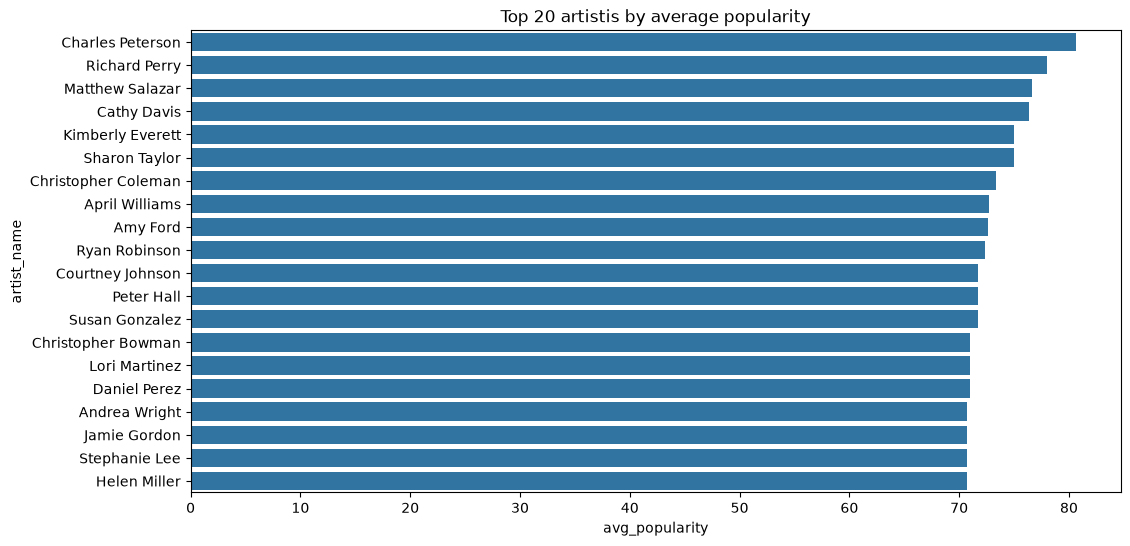

In [31]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=top_artists.reset_index(), x = 'avg_popularity', y='artist_name')
plt.title("Top 20 artistis by average popularity")
plt.show()